# AuraTune Genre/Mood Classifier — Model Review

Reviews the 3 models trained by `ml/train.py` on the
[Spotify Tracks Dataset](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset)
(114,000 real tracks) to predict one of 8 EQ-relevant genre buckets, which
`agents/genre_agent.py` uses to lean AuraTune's EQ curve for music content.

This notebook **loads the already-trained models** from `ml/models/` and
evaluates them — it does not retrain (run `python ml/train.py` for that).
See `ml/README.md` for the full write-up, including the accuracy-tuning
process (feature engineering + a small hyperparameter search against the
validation set) that took the best model from 50% to 53% test accuracy.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch

ML_DIR = Path.cwd() if (Path.cwd() / "train.py").exists() else Path.cwd() / "ml"
sys.path.insert(0, str(ML_DIR))
sys.path.insert(0, str(ML_DIR.parent))

from train import load_and_clean, GENRE_TO_BUCKET, SEED, DATA_CSV, key_to_sin_cos
from model_def import GenreMLP, GENRE_BUCKETS, FEATURE_COLUMNS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
MODELS_DIR = ML_DIR / "models"
print("Data file:", DATA_CSV)
print("Models dir:", MODELS_DIR)
print("Model input features:", FEATURE_COLUMNS)

Data file: C:\Users\ansha\CODING_AND_PROJECTS_ETC\capstone\Audio eq\auratune\auratune\ml\data\spotify_tracks_raw.csv
Models dir: C:\Users\ansha\CODING_AND_PROJECTS_ETC\capstone\Audio eq\auratune\auratune\ml\models
Model input features: ['danceability', 'energy', 'key_sin', 'key_cos', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


## 1. Load & explore the raw dataset

114,000 real Spotify tracks, 114 fine-grained genre tags, real audio
features pulled from Spotify's own audio-analysis API.

In [2]:
df_raw = pd.read_csv(DATA_CSV)
print(df_raw.shape, "rows x columns")
df_raw[["track_name", "artists", "track_genre", "danceability", "energy", "key",
        "loudness", "mode", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence", "tempo", "time_signature"]].head()

(114000, 21) rows x columns


,track_name,artists,track_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,Comedy,Gen Hoshino,acoustic,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,Ghost - Acoustic,Ben Woodward,acoustic,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,Can't Help Falling In Love,Kina Grannis,acoustic,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,Hold On,Chord Overstreet,acoustic,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


In [3]:
print(df_raw["track_genre"].nunique(), "unique genre tags")
print("nulls:\n", df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("duplicate (track_id, genre) rows:", df_raw.duplicated(subset=["track_id", "track_genre"]).sum())

114 unique genre tags
nulls:
 artists       1
album_name    1
track_name    1
dtype: int64


duplicate (track_id, genre) rows: 450


## 2. Data mining: 114 genre tags → 8 EQ-relevant buckets

A genre classifier is only useful to AuraTune if its output space maps to
something the EQ Decision agent can act on. `GENRE_TO_BUCKET` (in
`ml/train.py`) maps every raw tag to one of 8 buckets, each with its own
hand-tuned EQ deltas (`dsp/genre_curves.py`). This is a simplification for
EQ-tuning purposes, not a musicological taxonomy.

113550 rows after cleaning (dropped nulls + exact dupes), 8 genre buckets


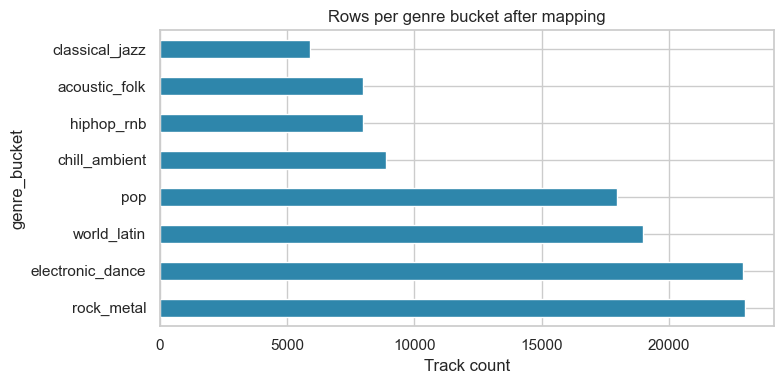

In [4]:
df = load_and_clean()
print(f"{len(df)} rows after cleaning (dropped nulls + exact dupes), "
      f"{df['genre_bucket'].nunique()} genre buckets")

fig, ax = plt.subplots(figsize=(8, 4))
df["genre_bucket"].value_counts().plot.barh(ax=ax, color="#2E86AB")
ax.set_xlabel("Track count")
ax.set_title("Rows per genre bucket after mapping")
plt.tight_layout()
plt.show()

## 3. Feature engineering: cyclical key encoding

Spotify's "key" feature is a **categorical** pitch class (0-11, musically
circular — key 11 and key 0 are a semitone apart, not far apart). Feeding
it in as a raw ordinal number was actively misleading the linear model and
the neural net. `key_to_sin_cos()` replaces it with `key_sin`/`key_cos`,
which preserves that circularity.

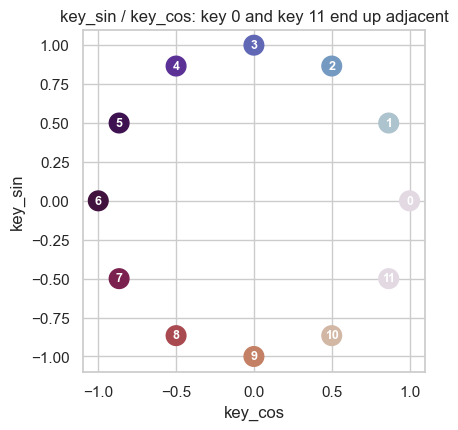

In [5]:
sample_keys = np.arange(12)
sin, cos = key_to_sin_cos(sample_keys)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(cos, sin, c=sample_keys, cmap="twilight", s=200, zorder=3)
for k, x, y in zip(sample_keys, cos, sin):
    ax.annotate(str(k), (x, y), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_title("key_sin / key_cos: key 0 and key 11 end up adjacent")
ax.set_xlabel("key_cos"); ax.set_ylabel("key_sin")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Feature overview

The 13 numeric features used as model input (12 Spotify features, minus categorical `key`, plus `key_sin`/`key_cos`).

In [6]:
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,113550.0,0.567031,0.173408,0.000,0.456000,5.800000e-01,0.695000,0.985
energy,113550.0,0.642090,0.251052,0.000,0.473000,6.850000e-01,0.854000,1.000
key_sin,113550.0,-0.034185,0.675432,-1.000,-0.500000,0.000000e+00,0.500000,1.000
key_cos,113550.0,0.037649,0.735672,-1.000,-0.866025,-1.836970e-16,0.866025,1.000
loudness,113550.0,-8.243419,5.011401,-49.531,-9.997750,-6.997000e+00,-5.001000,4.532
mode,113550.0,0.637860,0.480621,0.000,0.000000,1.000000e+00,1.000000,1.000
speechiness,113550.0,0.084674,0.105761,0.000,0.035900,4.890000e-02,0.084500,0.965
acousticness,113550.0,0.314067,0.331907,0.000,0.016800,1.680000e-01,0.596000,0.996
instrumentalness,113550.0,0.155702,0.309216,0.000,0.000000,4.130000e-05,0.048675,1.000
liveness,113550.0,0.213611,0.190461,0.000,0.098000,1.320000e-01,0.273000,1.000


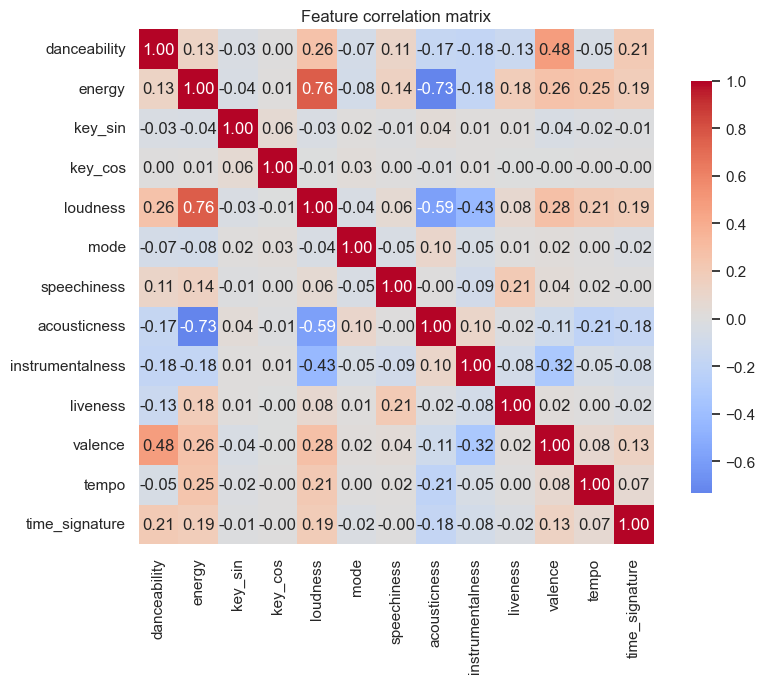

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 5. Reproduce the train/val/test split

Same seed, same stratified split as `ml/train.py`, so this notebook
evaluates the saved models on the exact held-out test set they were
scored on during training.

In [8]:
X = df[FEATURE_COLUMNS].values.astype(np.float32)
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder().fit(GENRE_BUCKETS)
y = label_enc.transform(df["genre_bucket"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=SEED, stratify=y_train)

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

scaler = joblib.load(MODELS_DIR / "scaler.joblib")
X_test_s = scaler.transform(X_test)

train=81756  val=9084  test=22710


## 6. Load the 3 trained models

In [9]:
logreg = joblib.load(MODELS_DIR / "logistic_regression.joblib")
hgb = joblib.load(MODELS_DIR / "gradient_boosting.joblib")

nn = GenreMLP()
nn.load_state_dict(torch.load(MODELS_DIR / "neural_net.pt", map_location="cpu", weights_only=True))
nn.eval()

metrics = json.loads((MODELS_DIR / "metrics.json").read_text())
print("Best model per training run:", metrics["best_model"])
print("\nSaved training-time metrics:")
for name, r in metrics["results"].items():
    print(f"  {name:<22} acc={r['accuracy']:.4f}  f1_macro={r['f1_macro']:.4f}")

Best model per training run: gradient_boosting

Saved training-time metrics:
  logistic_regression    acc=0.4011  f1_macro=0.3247
  gradient_boosting      acc=0.5312  f1_macro=0.4882
  neural_net             acc=0.4822  f1_macro=0.4222


## 7. Evaluate all 3 on the held-out test set

Re-scored here (not just trusting the saved numbers) as an independent check.

In [10]:
results = {}

pred_lr = logreg.predict(X_test_s)
results["logistic_regression"] = (accuracy_score(y_test, pred_lr), f1_score(y_test, pred_lr, average="macro"))

pred_hgb = hgb.predict(X_test_s)
results["gradient_boosting"] = (accuracy_score(y_test, pred_hgb), f1_score(y_test, pred_hgb, average="macro"))

with torch.no_grad():
    logits = nn(torch.tensor(X_test_s, dtype=torch.float32))
    pred_nn = logits.argmax(dim=1).numpy()
results["neural_net"] = (accuracy_score(y_test, pred_nn), f1_score(y_test, pred_nn, average="macro"))

results_df = pd.DataFrame(results, index=["accuracy", "f1_macro"]).T
results_df

C:\Users\ansha\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ansha\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateP

,accuracy,f1_macro
logistic_regression,0.401057,0.324733
gradient_boosting,0.531220,0.488197
neural_net,0.482166,0.422163


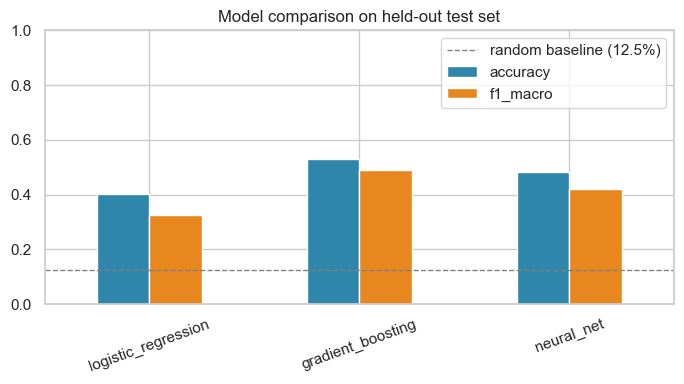

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df.plot.bar(ax=ax, color=["#2E86AB", "#E8871E"])
ax.set_ylim(0, 1)
ax.set_title("Model comparison on held-out test set")
ax.axhline(1 / len(GENRE_BUCKETS), color="gray", linestyle="--", linewidth=1, label="random baseline (12.5%)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
best_name = metrics["best_model"]
best_pred = {"logistic_regression": pred_lr, "gradient_boosting": pred_hgb, "neural_net": pred_nn}[best_name]
print(f"Classification report — {best_name} (best model):\n")
print(classification_report(y_test, best_pred, target_names=label_enc.classes_))

Classification report — gradient_boosting (best model):

                  precision    recall  f1-score   support

   acoustic_folk       0.53      0.49      0.51      1595
   chill_ambient       0.54      0.52      0.53      1777
  classical_jazz       0.45      0.36      0.40      1184
electronic_dance       0.62      0.70      0.65      4583
      hiphop_rnb       0.38      0.23      0.28      1597
             pop       0.41      0.38      0.39      3588
      rock_metal       0.61      0.67      0.64      4594
     world_latin       0.48      0.52      0.50      3792

        accuracy                           0.53     22710
       macro avg       0.50      0.48      0.49     22710
    weighted avg       0.52      0.53      0.52     22710



## 8. Confusion matrix (best model)

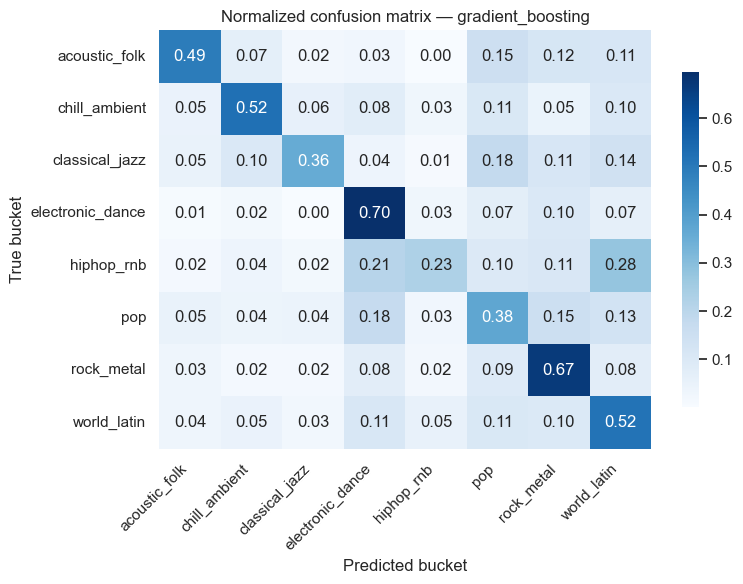

In [13]:
cm = confusion_matrix(y_test, best_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("True bucket")
ax.set_title(f"Normalized confusion matrix — {best_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Neural network training curve

Train vs. validation loss across all 200 epochs (`ml/train.py`'s saved
loss history) — the best checkpoint (lowest val loss) is the one actually
saved to `neural_net.pt`.

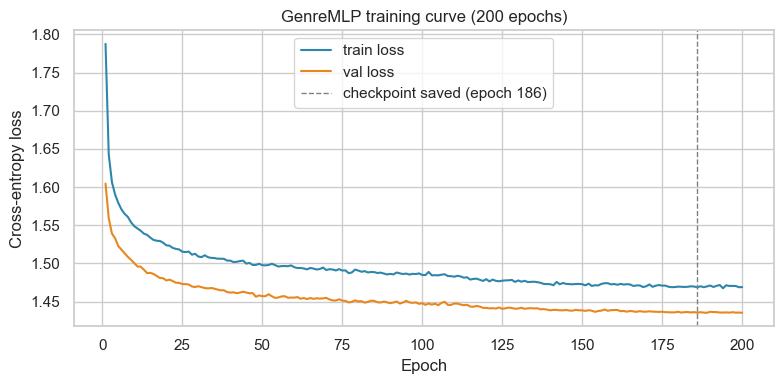

In [14]:
nn_metrics = metrics["results"]["neural_net"]
train_hist = nn_metrics["train_loss_history"]
val_hist = nn_metrics["val_loss_history"]
best_epoch = int(np.argmin(val_hist)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_hist) + 1), train_hist, label="train loss", color="#2E86AB")
ax.plot(range(1, len(val_hist) + 1), val_hist, label="val loss", color="#E8871E")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"checkpoint saved (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title(f"GenreMLP training curve ({len(train_hist)} epochs)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Gradient boosting feature importance (permutation-based)

`HistGradientBoostingClassifier` doesn't expose `.feature_importances_`
(unlike Random Forest), so this uses **permutation importance** instead:
shuffle one feature at a time on the test set and measure how much
accuracy drops. A bigger drop means the model relies on that feature more.

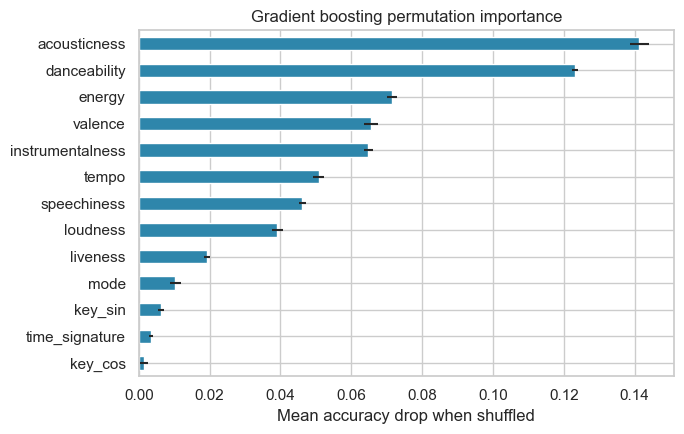

In [15]:
perm = permutation_importance(hgb, X_test_s, y_test, n_repeats=8,
                              random_state=SEED, scoring="accuracy", n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=FEATURE_COLUMNS).sort_values()
errors = pd.Series(perm.importances_std, index=FEATURE_COLUMNS)[importances.index]

fig, ax = plt.subplots(figsize=(7, 4.5))
importances.plot.barh(ax=ax, color="#2E86AB", xerr=errors)
ax.set_xlabel("Mean accuracy drop when shuffled")
ax.set_title("Gradient boosting permutation importance")
plt.tight_layout()
plt.show()

## 11. Live demo: classify AuraTune's own synthetic "music" scenario

Runs the exact same code path `agents/genre_agent.py` uses at inference
time — `perception/genre_classifier.py` turns raw audio into the 13 proxy
features via `librosa`, scales them, and predicts.

In [16]:
sys.path.insert(0, str(ML_DIR.parent))
from perception.synth_scenarios import synth_scenario
from perception import genre_classifier as gc

_, content = synth_scenario("noisy_music", sr=44100)
result = gc.classify_genre(content, sr=44100)

print("ok:", result.ok)
print("predicted bucket:", result.bucket)
print("confidence:", f"{result.confidence:.1%}")
print("model used:", result.model_used)
print("\nfull probability distribution:")
for bucket, p in sorted(result.all_probabilities.items(), key=lambda kv: -kv[1]):
    print(f"  {bucket:<20} {p:.1%}")
print("\nproxy audio features fed to the model:")
for k, v in result.proxy_features.items():
    print(f"  {k:<16} {v:.4f}")

ok: True
predicted bucket: chill_ambient
confidence: 74.0%
model used: gradient_boosting

full probability distribution:
  chill_ambient        74.0%
  electronic_dance     14.0%
  world_latin          5.2%
  pop                  4.4%
  classical_jazz       1.2%
  hiphop_rnb           0.6%
  acoustic_folk        0.4%
  rock_metal           0.2%

proxy audio features fed to the model:
  danceability     0.6882
  energy           0.7917
  key_sin          -1.0000
  key_cos          -0.0000
  loudness         -12.4988
  mode             0.0000
  speechiness      0.0000
  acousticness     0.9989
  instrumentalness 1.0000
  liveness         0.2000
  valence          0.0207
  tempo            120.0000
  time_signature   4.0000


## Takeaways

- **Accuracy tuning pass**: cyclically encoding the categorical `key`
  feature (instead of feeding it in as a raw ordinal number), switching
  from a plain `StandardScaler` to a Yeo-Johnson `PowerTransformer` (fixes
  the heavy right-skew in speechiness/acousticness/instrumentalness), and
  swapping Random Forest for a tuned `HistGradientBoostingClassifier`
  (hyperparameters picked via a small grid search against the *validation*
  set only) took the best model from 50.0% to **53.1%** test accuracy.
- "Balanced" class weighting was tried for all 3 models and measured
  *worse* on both accuracy and macro F1 for every one of them on this
  dataset's validation set, so it was left off, based on that evidence —
  not assumed as a default best practice.
- Gradient boosting is the strongest model (53.1% accuracy, 0.488 macro
  F1) on 8-class genre-bucket prediction from 13 numeric audio features —
  well above the 12.5% random baseline, but this remains a genuinely hard
  task (even Spotify's own 114-genre labels overlap heavily in feature
  space).
- `agents/genre_agent.py` blends predictions in by confidence
  (`GENRE_BLEND_WEIGHT * confidence`), so a shaky call only nudges the EQ
  curve rather than dominating it.
- See `ml/README.md` for the honest per-feature notes on how well each of
  the 13 inference-time proxy features actually approximates Spotify's
  real ones.